# CASE B — Real-trained correct, synthetic-trained wrong

CASE B contains test images for which the real-trained classifier predicts the
correct class, while the synthetic-trained classifier makes an incorrect
prediction.

The analysis compares Grad-CAM and Integrated Gradients explanations to
investigate how the decision mechanisms of the two classifiers differ when
training on synthetic data leads to a classification error.


### Analysis structure

CASE B is investigated through two complementary analyses:

1. **Cross-model analysis:** Integrated Gradients is used to compare the
   real-trained and synthetic-trained classifiers with respect to the true class.

2. **Synthetic-model analysis:** Grad-CAM and Integrated Gradients are used to
   investigate the synthetic-trained classifier, comparing the evidence associated
   with the true class and with the incorrectly predicted class.

The two analyses use different Integrated Gradients implementations and baselines,
and their attribution magnitudes are therefore interpreted separately.


### Prerequisites

If CIFAR-10 is not available in the cache or under `Data/`, set
`ALLOW_CIFAR10_DOWNLOAD=1` before loading it.


In [1]:
from pathlib import Path
import sys

# Set an absolute path only if the notebook is not in the project root.
PROJECT_DIR_OVERRIDE = None  # example: Path("/content/interpretability-project")


def find_project_dir(start=None):
    required = (
        Path("Models/ImageClassifiers/resnet.py"),
        Path("scripts/classifier_part/cifar10_utils.py"),
        Path("scripts/classifier_part/xai_metrics.py"),
    )
    if PROJECT_DIR_OVERRIDE is not None:
        candidate = Path(PROJECT_DIR_OVERRIDE).expanduser().resolve()
        if all((candidate / item).exists() for item in required):
            return candidate
        raise FileNotFoundError(
            f"PROJECT_DIR_OVERRIDE does not contain all required files: {candidate}"
        )

    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if all((candidate / item).exists() for item in required):
            return candidate
    raise FileNotFoundError(
        "Project root not found. Place the notebook, cifar10_utils.py, and "
        "xai_metrics.py in the root or set PROJECT_DIR_OVERRIDE."
    )


PROJECT_DIR = find_project_dir()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("Project directory:", PROJECT_DIR)


Project directory: /home/matteo.doria/Desktop/xAI-Project


In [2]:
import csv
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from xplique.attributions import IntegratedGradients

from Models.ImageClassifiers.resnet import ResNet20
from scripts.classifier_part.cifar10_utils import load_cifar10_test_data
from scripts.classifier_part.xai_metrics import (
    CIFAR10_MEAN,
    deletion_insertion_auc,
    pearson_correlation,
    resize_saliency,
    saliency_to_2d,
    top_fraction_iou,
)

SEED = 1234
CIFAR10_CLASSES = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
)

np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


2026-09-24 11:19:44.219026: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-24 11:19:44.260924: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-24 11:19:44.262023: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-24 11:19:47.750661: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [3]:
SAVE_DIR = PROJECT_DIR / "Models/Checkpoints/Classifiers/resnet20"

REAL_MODEL_PATH = SAVE_DIR / "resnet20_real_matched.h5"
SYNTHETIC_MODEL_PATH = SAVE_DIR / "resnet20_synthetic.h5"

# All CASE B artefacts live here (git-ignored, shipped with the data archive).
CASE_B_DIR = PROJECT_DIR / "Results/Exp_xAI/cifar10/classifier/caseB"

# Set to True to recompute everything on GPU even if saved results exist.
FORCE_RECOMPUTE = False

# Shared by all CASE B analyses.
CASE_B_INDICES_PATH = CASE_B_DIR / "caseB_test_indices.npy"

# Cross-model Integrated Gradients analysis
MAX_IMAGES_PER_CLASS = 100
IMAGES_PER_CLASS = MAX_IMAGES_PER_CLASS  # original name preserved
IG_STEPS = 50
MASKING_FRACTION = 0.10
IG_REPORT_OUTPUT_DIR = CASE_B_DIR / "cross_model_ig"
SUMMARY_BY_CLASS_CSV = IG_REPORT_OUTPUT_DIR / "CaseB_Summary_ByClass.csv"
CROSS_MODEL_IG_PATH = IG_REPORT_OUTPUT_DIR / "caseB_cross_model_ig_maps.npz"

# Synthetic-model Grad-CAM and Integrated Gradients analysis
SYNTHETIC_ONLY_OUTPUT_DIR = CASE_B_DIR / "synthetic_model"
SYNTHETIC_PER_IMAGE_CSV = SYNTHETIC_ONLY_OUTPUT_DIR / "caseB_synthetic_only_per_image_metrics.csv"
SYNTHETIC_MASKING_CSV = SYNTHETIC_ONLY_OUTPUT_DIR / "caseB_masking_per_image.csv"
SYNTHETIC_ONLY_IG_STEPS = 64
TOP_FRACTION = 0.20
MASKING_FRACTIONS = (0.00, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50)
SAVE_RAW = False

# LIME
LIME_CASE_B_DIR = CASE_B_DIR / "lime"
LIME_CASE_B_VISUALS_DIR = LIME_CASE_B_DIR / "visuals"
LIME_CASE_B_PER_IMAGE_CSV = LIME_CASE_B_DIR / "lime_caseB_per_image.csv"
LIME_CASE_B_MASKING_CSV = LIME_CASE_B_DIR / "lime_caseB_masking_per_image.csv"

## 1. Load models and compute test predictions

Load the real-trained and synthetic-trained ResNet20 classifiers and the real
CIFAR-10 test set. Predictions are computed on the complete test set to obtain
the overall test accuracy of both models and to support the subsequent CASE B
selection.

The final spatial layer is also identified for the Grad-CAM analysis, and
auxiliary models are prepared to access pre-softmax logits and class
probabilities.

In [4]:
def create_resnet20():
    return ResNet20(
        input_shape=(32, 32, 3),
        num_classes=10,
        initial_filters=16,
        seed=SEED,
    )


def load_trained_resnet(path):
    model = create_resnet20()
    try:
        model.load_weights(str(path))
        return model
    except Exception:
        try:
            return tf.keras.models.load_model(
                str(path),
                compile=False,
                custom_objects={"ResNet20": ResNet20},
            )
        except Exception as model_error:
            raise RuntimeError(f"Unable to load the model: {path}") from model_error


def find_last_spatial_layer(model):
    for layer in reversed(model.layers):
        try:
            if len(layer.output.shape) == 4:
                return layer.name
        except AttributeError:
            continue
    raise ValueError("No spatial layer was found in the model.")


def build_logit_model(model):
    classifier = model.layers[-1]
    feature_model = tf.keras.Model(model.inputs, classifier.input)
    return feature_model, classifier


def logits_and_probabilities(feature_model, classifier, images):
    features = feature_model(images, training=False)
    logits = tf.linalg.matmul(features, classifier.kernel)
    if classifier.use_bias:
        logits = logits + classifier.bias
    probabilities = tf.nn.softmax(logits)
    return logits, probabilities


In [5]:
missing_checkpoints = [
    path for path in (REAL_MODEL_PATH, SYNTHETIC_MODEL_PATH) if not path.exists()
]
if missing_checkpoints:
    raise FileNotFoundError(
        "Missing checkpoints: extract them from the data archive, or train them "
        "with python -m scripts.classifier_part.run_train_real_synth:\n"
        + "\n".join(f"- {path}" for path in missing_checkpoints)
    )

x_test, y_test = load_cifar10_test_data()
model_real = load_trained_resnet(REAL_MODEL_PATH)
model_synthetic = load_trained_resnet(SYNTHETIC_MODEL_PATH)
models = {"real": model_real, "synthetic": model_synthetic}

all_model_probabilities = {
    name: model.predict(x_test, batch_size=256, verbose=0)
    for name, model in models.items()
}
predictions = {
    name: np.argmax(values, axis=1)
    for name, values in all_model_probabilities.items()
}

accuracy_df = pd.DataFrame({
    "model": ["real-trained", "synthetic-trained"],
    "test_accuracy": [
        np.mean(predictions["real"] == y_test),
        np.mean(predictions["synthetic"] == y_test),
    ],
})
display(accuracy_df.round(3))


2026-09-24 11:20:00.634696: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


,model,test_accuracy
0,real-trained,0.770
1,synthetic-trained,0.713


## 2. CASE B selection

CASE B is defined on the complete real test set as images correctly classified
by the real-trained model and incorrectly classified by the synthetic-trained
model.


Up to 100 eligible images are then randomly selected per class. The same
selected images are used throughout all subsequent CASE B explainability
analyses

In [6]:
def select_case_b_indices(y_true, eligibility, max_images_per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    selected = []
    for class_id in range(len(CIFAR10_CLASSES)):
        candidates = np.where((y_true == class_id) & eligibility)[0]
        sample_size = min(int(max_images_per_class), len(candidates))
        chosen = rng.choice(candidates, size=sample_size, replace=False)
        selected.extend(chosen.tolist())
    rng.shuffle(selected)
    return np.asarray(selected, dtype=int)


# Descriptive statistics on the complete test set: cheap, always recomputed.
case_b_mask = (predictions["real"] == y_test) & (predictions["synthetic"] != y_test)
case_b_all_indices = np.where(case_b_mask)[0]

CASE_B_DIR.mkdir(parents=True, exist_ok=True)

if CASE_B_INDICES_PATH.exists() and not FORCE_RECOMPUTE:
    selected_indices = np.load(CASE_B_INDICES_PATH)
    print("CASE B indices loaded from:", CASE_B_INDICES_PATH)
else:
    selected_indices = select_case_b_indices(y_test, case_b_mask, MAX_IMAGES_PER_CLASS)
    if len(selected_indices) == 0:
        raise RuntimeError("No image satisfies the CASE B definition.")
    np.save(CASE_B_INDICES_PATH, selected_indices)
    print("CASE B indices saved to:", CASE_B_INDICES_PATH)

# Sanity check: CASE B images are borderline by definition, so on a different
# machine a few may flip prediction.
print(f"Still CASE B on this machine: {case_b_mask[selected_indices].sum()}/{len(selected_indices)}")

case_b_counts = pd.DataFrame([
    {
        "true_class_id": class_id,
        "true_class_name": class_name,
        "test_images": int(np.sum(y_test == class_id)),
        "available_case_b": int(np.sum((y_test == class_id) & case_b_mask)),
        "case_b_rate_full_test": float(np.mean(case_b_mask[y_test == class_id])),
        "selected_case_b": int(np.sum(y_test[selected_indices] == class_id)),
    }
    for class_id, class_name in enumerate(CIFAR10_CLASSES)
])

case_b = []
for test_index in selected_indices:
    true_class = int(y_test[test_index])
    case_b.append({
        "index": int(test_index),
        "image": x_test[test_index],
        "true_class": true_class,
        "synthetic_prediction": int(predictions["synthetic"][test_index]),
        "prediction_real": all_model_probabilities["real"][test_index],
        "prediction_synthetic": all_model_probabilities["synthetic"][test_index],
    })

IG_REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
case_b_counts.to_csv(
    IG_REPORT_OUTPUT_DIR / "CaseB_Selection_Counts.csv", index=False
)
display(case_b_counts.round(3))
print("CASE B cases available in the complete test set:", len(case_b_all_indices))
print("CASE B cases selected for XAI:", len(selected_indices))

CASE B indices loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/caseB_test_indices.npy
Still CASE B on this machine: 901/901


,true_class_id,true_class_name,test_images,available_case_b,case_b_rate_full_test,selected_case_b
0,0,airplane,1000,92,0.092,92
1,1,automobile,1000,81,0.081,81
2,2,bird,1000,150,0.150,100
3,3,cat,1000,276,0.276,100
4,4,deer,1000,175,0.175,100
5,5,dog,1000,218,0.218,100
6,6,frog,1000,35,0.035,35
7,7,horse,1000,133,0.133,100
8,8,ship,1000,128,0.128,100
9,9,truck,1000,93,0.093,93


CASE B cases available in the complete test set: 1381
CASE B cases selected for XAI: 901


A confusion matrix is computed using all CASE B images in the test set,
independently of the per-class sampling used for the explainability analyses.

Rows correspond to the true class, while columns correspond to the incorrect
class predicted by the synthetic-trained classifier.


In [7]:
full_true_names = pd.Categorical(
    [CIFAR10_CLASSES[i] for i in y_test[case_b_all_indices]],
    categories=CIFAR10_CLASSES,
    ordered=True,
)
full_wrong_names = pd.Categorical(
    [CIFAR10_CLASSES[i] for i in predictions["synthetic"][case_b_all_indices]],
    categories=CIFAR10_CLASSES,
    ordered=True,
)
full_case_b_confusion = pd.crosstab(
    full_true_names, full_wrong_names, dropna=False
)
full_case_b_confusion.index.name = "true_class"
full_case_b_confusion.columns.name = "synthetic_prediction"
full_case_b_confusion.to_csv(
    IG_REPORT_OUTPUT_DIR / "CaseB_Confusion_AllEligible.csv"
)
display(full_case_b_confusion)


synthetic_prediction,airplane,automobile,bird,cat,deer,dog,frog,horse,ship,truck
true_class,,,,,,,,,,
airplane,0,10,36,0,12,1,4,4,17,8
automobile,13,0,3,0,0,0,19,3,10,33
bird,33,2,0,10,29,8,50,11,1,6
cat,20,10,29,0,42,29,107,13,16,10
deer,19,1,39,8,0,2,80,24,1,1
dog,7,4,29,42,15,0,64,42,8,7
frog,7,2,15,2,4,2,0,1,2,0
horse,22,2,17,6,45,7,31,0,1,2
ship,68,20,7,2,7,2,6,5,0,11


## 3. Cross-model Integrated Gradients analysis

Integrated Gradients is computed for the true class on both the real-trained
and synthetic-trained classifiers.

Only positive attributions are retained and normalized to unit mass, allowing
the spatial distribution of true-class evidence to be compared independently
of its absolute magnitude.

Missing evidence is defined as the positive part of the difference between the
normalized real-trained and synthetic-trained attribution maps. Agreement is
measured using cosine similarity and Top-20% IoU.

To assess the functional relevance of the missing-evidence regions, the top 10%
of these regions are masked and the resulting drop in true-class confidence of
the real-trained classifier is measured.

In [8]:
def predict(model, image):
    return model(
        image[None, ...],
        training=False,
    )[0].numpy()


def compute_ig(
    explainer,
    image,
    target_class,
):
    target = tf.one_hot(
        [target_class],
        depth=10,
    )

    attribution = explainer.explain(
        image[None, ...],
        target,
    )

    return (
        attribution
        .numpy()[0]
        .squeeze()
    )


def positive_ig(ig):
    return np.maximum(
        ig,
        0,
    )


def normalize_mass(attribution):
    """
    Normalize positive attribution so that total mass = 1.
    Used only to compare the spatial distribution of evidence.
    """
    total = np.sum(attribution)

    if total > 0:
        return attribution / total

    return attribution.copy()


def compute_missing_evidence(
    ig_real,
    ig_synthetic,
):
    """
    Evidence for the TRUE class that is relatively more
    important for Real-trained than Synthetic-trained.

    Steps:
    1. Keep only positive IG.
    2. Normalize each positive map to total mass = 1.
    3. Compute positive part of Real - Synthetic.
    """

    real_positive = positive_ig(
        ig_real
    )

    synthetic_positive = positive_ig(
        ig_synthetic
    )

    real_normalized = normalize_mass(
        real_positive
    )

    synthetic_normalized = normalize_mass(
        synthetic_positive
    )

    missing = np.maximum(
        real_normalized
        - synthetic_normalized,
        0,
    )

    return (
        real_normalized,
        synthetic_normalized,
        missing,
    )


def cosine_similarity(a, b):
    a = a.flatten()
    b = b.flatten()

    denominator = (
        np.linalg.norm(a)
        * np.linalg.norm(b)
    )

    if denominator == 0:
        return 0.0

    return float(
        np.dot(a, b)
        / denominator
    )



def missing_evidence_mass(missing):
    return float(
        np.sum(missing)
    )


def mask_missing_evidence(
    image,
    missing,
    fraction,
):
    """
    Mask the pixels with the highest missing evidence.
    """

    modified = image.copy()

    flat_missing = (
        missing.flatten()
    )

    number_pixels = max(
        1,
        int(
            fraction
            * len(flat_missing)
        ),
    )

    ranking = np.argsort(
        flat_missing
    )[::-1]

    pixels_to_mask = (
        ranking[:number_pixels]
    )

    rows, cols = np.unravel_index(
        pixels_to_mask,
        missing.shape,
    )

    # Same black baseline used by IG
    modified[
        rows,
        cols,
        :
    ] = 0.0

    return modified


def normalize_for_display(attribution):
    maximum = np.max(
        attribution
    )

    if maximum > 0:
        return attribution / maximum

    return attribution



In [9]:
# 1. IG maps: the only expensive part, computed once on GPU and then loaded.
if CROSS_MODEL_IG_PATH.exists() and not FORCE_RECOMPUTE:
    with np.load(CROSS_MODEL_IG_PATH) as saved_ig:
        cross_ig_real = saved_ig["ig_real"]
        cross_ig_synthetic = saved_ig["ig_synthetic"]
        cross_ig_indices = saved_ig["selected_indices"]
    print("Cross-model IG maps loaded from:", CROSS_MODEL_IG_PATH)
else:
    ig_real_explainer = IntegratedGradients(
        model_real,
        steps=IG_STEPS,
        baseline_value=0.0,
    )
    ig_synthetic_explainer = IntegratedGradients(
        model_synthetic,
        steps=IG_STEPS,
        baseline_value=0.0,
    )

    cross_ig_real = []
    cross_ig_synthetic = []
    for number, sample in enumerate(case_b, start=1):
        cross_ig_real.append(
            compute_ig(ig_real_explainer, sample["image"], sample["true_class"])
        )
        cross_ig_synthetic.append(
            compute_ig(ig_synthetic_explainer, sample["image"], sample["true_class"])
        )
        if number % 25 == 0 or number == len(case_b):
            print(f"IG cross-model: {number}/{len(case_b)} images")

    cross_ig_real = np.asarray(cross_ig_real)
    cross_ig_synthetic = np.asarray(cross_ig_synthetic)
    cross_ig_indices = selected_indices.copy()
    np.savez(
        CROSS_MODEL_IG_PATH,
        ig_real=cross_ig_real,
        ig_synthetic=cross_ig_synthetic,
        selected_indices=cross_ig_indices,
    )
    print("Cross-model IG maps saved to:", CROSS_MODEL_IG_PATH)

# Maps are paired with case_b by position: same images, same order.
assert np.array_equal(cross_ig_indices, selected_indices), (
    "Saved cross-model IG maps do not match the CASE B indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

# 2. Metrics and figure candidates: cheap, always recomputed from the maps.
results = []
figure_candidates = {
    class_name: [] for class_name in CIFAR10_CLASSES
}

for position, sample in enumerate(case_b):
    image = sample["image"]
    true_class = sample["true_class"]
    synthetic_prediction = sample["synthetic_prediction"]
    true_name = CIFAR10_CLASSES[true_class]
    wrong_name = CIFAR10_CLASSES[synthetic_prediction]

    ig_real = cross_ig_real[position]
    ig_synthetic = cross_ig_synthetic[position]
    real_normalized, synthetic_normalized, missing = compute_missing_evidence(
        ig_real,
        ig_synthetic,
    )

    cosine = cosine_similarity(real_normalized, synthetic_normalized)
    iou = top_fraction_iou(
        real_normalized,
        synthetic_normalized,
        top_fraction=0.20,
    )
    missing_mass = missing_evidence_mass(missing)

    real_p_true = float(sample["prediction_real"][true_class])
    synthetic_p_true = float(sample["prediction_synthetic"][true_class])

    masked_image = mask_missing_evidence(
        image,
        missing,
        MASKING_FRACTION,
    )
    masked_prediction = predict(model_real, masked_image)
    real_p_true_after_mask = float(masked_prediction[true_class])
    mask10_drop = real_p_true - real_p_true_after_mask

    results.append({
        "test_index": sample["index"],
        "true_class": true_name,
        "synthetic_prediction": wrong_name,
        "real_p_true": real_p_true,
        "synthetic_p_true": synthetic_p_true,
        "cosine_similarity": cosine,
        "top20_iou": iou,
        "missing_evidence_mass": missing_mass,
        "mask10_confidence_drop": mask10_drop,
    })

    figure_candidates[true_name].append({
        "image": image,
        "synthetic_prediction_name": wrong_name,
        "real_normalized": real_normalized,
        "synthetic_normalized": synthetic_normalized,
        "missing": missing,
        "missing_evidence_mass": missing_mass,
    })

cross_model_ig_df = pd.DataFrame(results)
display(cross_model_ig_df.head())

Cross-model IG maps loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/cross_model_ig/caseB_cross_model_ig_maps.npz


,test_index,true_class,synthetic_prediction,real_p_true,synthetic_p_true,cosine_similarity,top20_iou,missing_evidence_mass,mask10_confidence_drop
0,4508,truck,cat,0.996110,0.003400,0.359300,0.154930,0.686204,0.974827
1,3208,truck,ship,0.985199,0.183394,0.346138,0.174785,0.692290,0.910775
2,9113,automobile,frog,0.999945,0.011338,0.383127,0.161473,0.690596,0.996962
3,455,deer,bird,0.916942,0.001347,0.298201,0.145251,0.705937,0.916942
4,6532,dog,horse,0.918464,0.000132,0.408724,0.216617,0.650622,0.908096


### Cross-model IG results

Results are summarized overall and by true class, including CASE B frequency,
true-class confidence, attribution agreement, missing-evidence mass, and the
effect of masking missing-evidence regions.



,true_class,N_case_B,case_B_rate,N_case_B_available,N_analyzed,real_p_true_mean,synthetic_p_true_mean,cosine_mean,cosine_std,top20_iou_mean,top20_iou_std,missing_evidence_mean,missing_evidence_std,mask10_confidence_drop_mean,mask10_confidence_drop_std
0,airplane,92,0.0920,92,92,0.8667,0.1031,0.3521,0.0463,0.1778,0.0272,0.6846,0.0272,0.6122,0.3675
1,automobile,81,0.0810,81,81,0.9175,0.1103,0.3651,0.0630,0.1936,0.0308,0.6780,0.0309,0.7093,0.3340
2,bird,100,0.1500,150,100,0.8695,0.0927,0.3431,0.0543,0.1793,0.0287,0.6857,0.0308,0.8229,0.1944
3,cat,100,0.2760,276,100,0.8990,0.0607,0.3388,0.0544,0.1822,0.0314,0.6942,0.0295,0.7636,0.2724
4,deer,100,0.1750,175,100,0.9163,0.1095,0.3417,0.0473,0.1726,0.0266,0.6897,0.0246,0.8766,0.1979
5,dog,100,0.2180,218,100,0.9151,0.0654,0.3360,0.0461,0.1834,0.0294,0.6924,0.0252,0.9051,0.1658
6,frog,35,0.0350,35,35,0.8899,0.1650,0.3302,0.0507,0.1745,0.0275,0.6985,0.0254,0.6828,0.3238
7,horse,100,0.1330,133,100,0.8799,0.0793,0.3381,0.0421,0.1774,0.0255,0.6901,0.0242,0.4881,0.4011
8,ship,100,0.1280,128,100,0.9110,0.1005,0.3713,0.0599,0.1905,0.0296,0.6752,0.0315,0.8630,0.2205
9,truck,93,0.0930,93,93,0.8883,0.0960,0.3720,0.0543,0.1851,0.0289,0.6726,0.0297,0.8245,0.2455


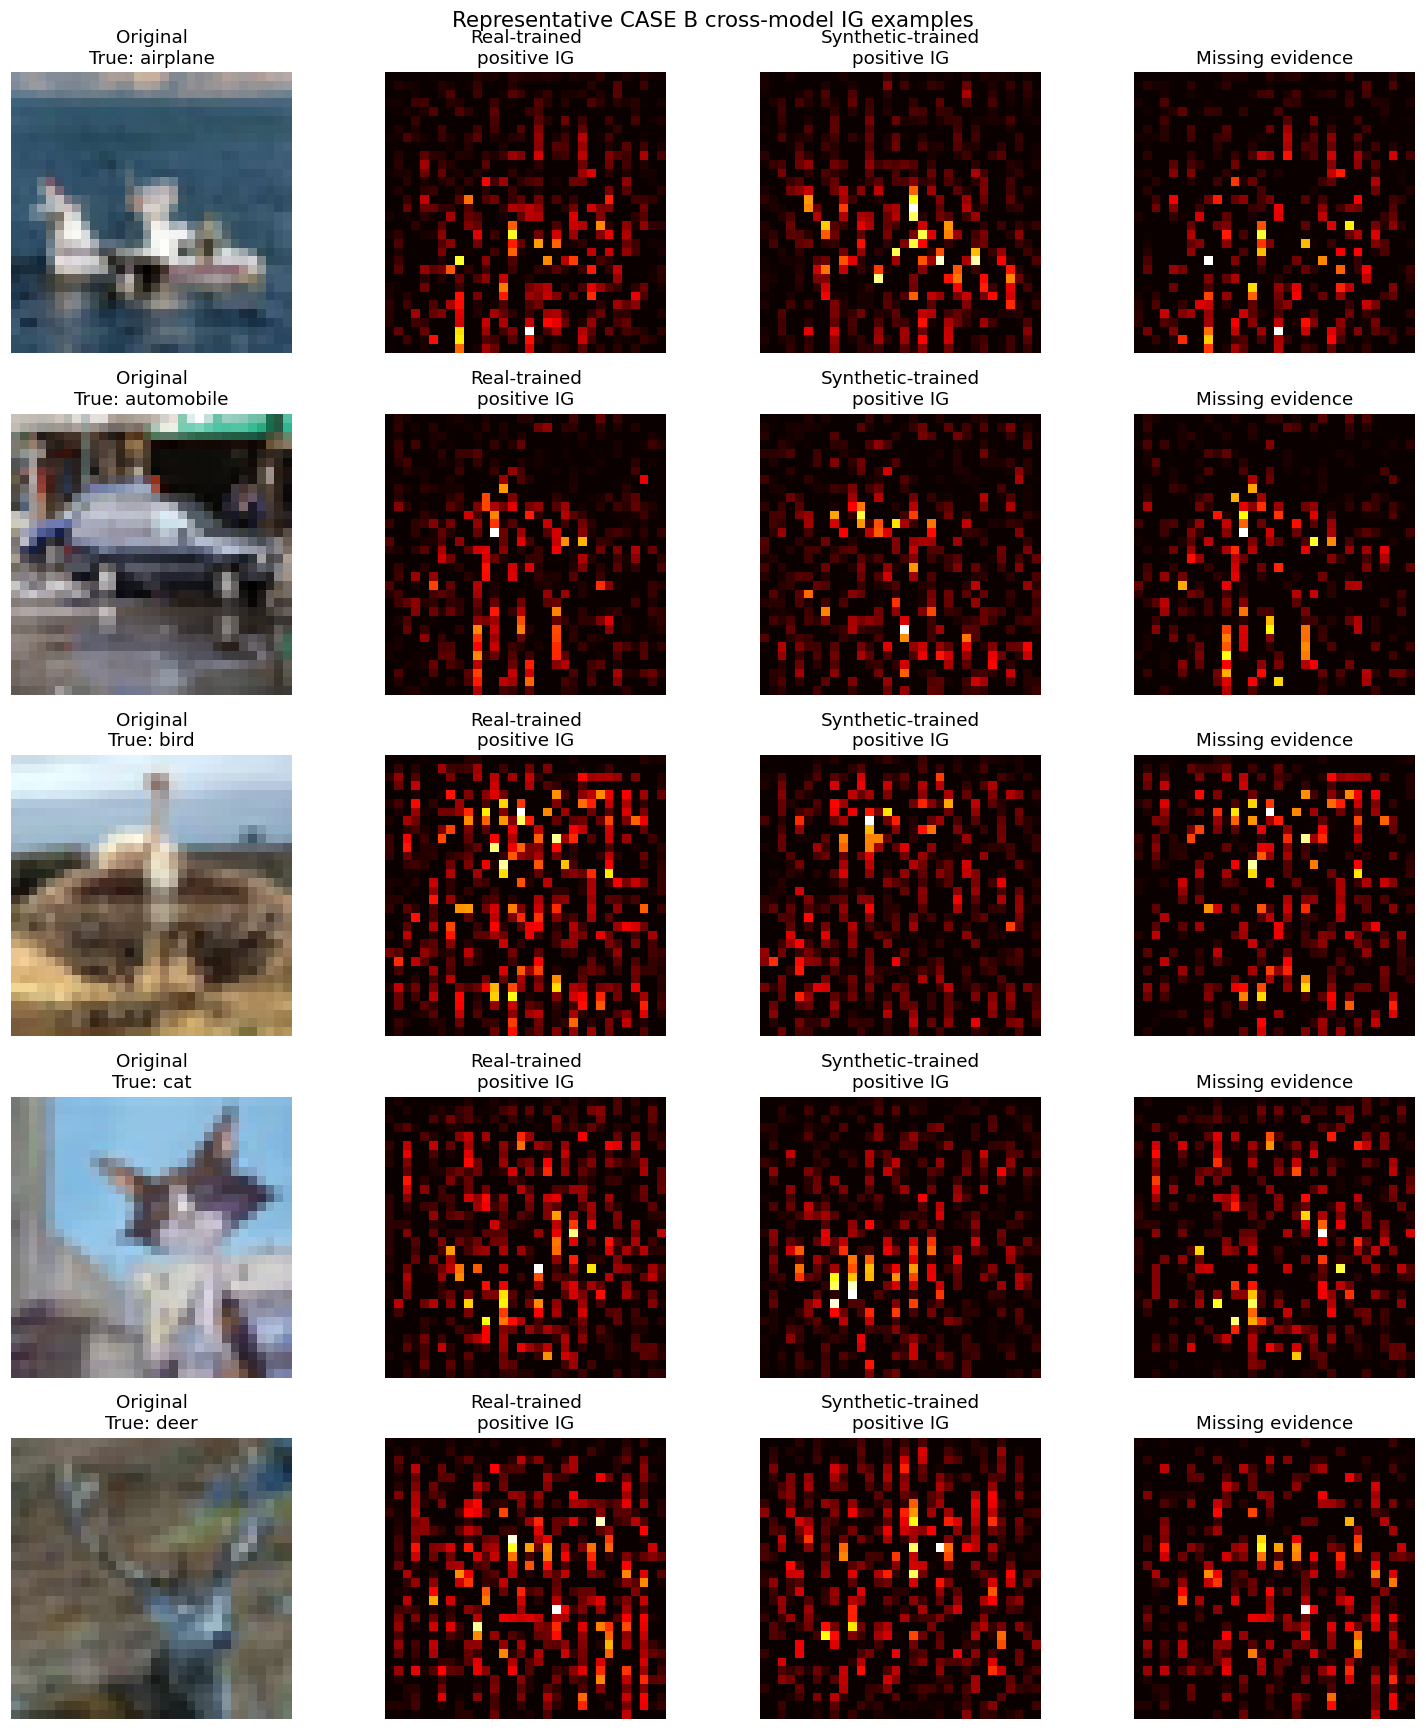

Cross-model IG output: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/cross_model_ig


In [10]:
counts_lookup = case_b_counts.set_index("true_class_name")
summary_rows = []

for class_id, class_name in enumerate(CIFAR10_CLASSES):
    class_df = cross_model_ig_df[
        cross_model_ig_df["true_class"] == class_name
    ]

    available = int(
        counts_lookup.loc[class_name, "available_case_b"]
    )

    test_images = int(
        counts_lookup.loc[class_name, "test_images"]
    )

    analyzed = len(class_df)

    row = {
        "true_class": class_name,
        "N_case_B": analyzed,
        "case_B_rate": available / test_images,
        "N_case_B_available": available,
        "N_analyzed": analyzed,
    }

    for output_name, source_name in (
        ("real_p_true", "real_p_true"),
        ("synthetic_p_true", "synthetic_p_true"),
    ):
        row[f"{output_name}_mean"] = (
            class_df[source_name].mean()
            if analyzed else np.nan
        )

    for output_name, source_name in (
        ("cosine", "cosine_similarity"),
        ("top20_iou", "top20_iou"),
        ("missing_evidence", "missing_evidence_mass"),
        ("mask10_confidence_drop", "mask10_confidence_drop"),
    ):
        row[f"{output_name}_mean"] = (
            class_df[source_name].mean()
            if analyzed else np.nan
        )

        row[f"{output_name}_std"] = (
            class_df[source_name].std()
            if analyzed else np.nan
        )

    summary_rows.append(row)


summary_by_class = pd.DataFrame(summary_rows)

overall = {
    "true_class": "OVERALL",
    "N_case_B": len(cross_model_ig_df),
    "case_B_rate": len(case_b_all_indices) / len(y_test),
    "N_case_B_available": len(case_b_all_indices),
    "N_analyzed": len(cross_model_ig_df),

    "real_p_true_mean":
        cross_model_ig_df["real_p_true"].mean(),

    "synthetic_p_true_mean":
        cross_model_ig_df["synthetic_p_true"].mean(),

    "cosine_mean":
        cross_model_ig_df["cosine_similarity"].mean(),

    "cosine_std":
        cross_model_ig_df["cosine_similarity"].std(),

    "top20_iou_mean":
        cross_model_ig_df["top20_iou"].mean(),

    "top20_iou_std":
        cross_model_ig_df["top20_iou"].std(),

    "missing_evidence_mean":
        cross_model_ig_df[
            "missing_evidence_mass"
        ].mean(),

    "missing_evidence_std":
        cross_model_ig_df[
            "missing_evidence_mass"
        ].std(),

    "mask10_confidence_drop_mean":
        cross_model_ig_df[
            "mask10_confidence_drop"
        ].mean(),

    "mask10_confidence_drop_std":
        cross_model_ig_df[
            "mask10_confidence_drop"
        ].std(),
}

summary_by_class.loc[
    len(summary_by_class)
] = overall

numeric_columns = (
    summary_by_class
    .select_dtypes(include="number")
    .columns
)

summary_by_class[
    numeric_columns
] = summary_by_class[
    numeric_columns
].round(4)

summary_by_class.to_csv(
    SUMMARY_BY_CLASS_CSV,
    index=False,
)

display(summary_by_class)


representative_examples = []

for class_id, class_name in enumerate(
    CIFAR10_CLASSES
):
    candidates = figure_candidates[class_name]

    if not candidates:
        continue

    masses = np.asarray([
        candidate["missing_evidence_mass"]
        for candidate in candidates
    ])

    median_mass = np.median(masses)

    representative_index = int(
        np.argmin(
            np.abs(
                masses - median_mass
            )
        )
    )

    representative_examples.append(
        (
            class_id,
            class_name,
            candidates[representative_index],
        )
    )


N_REPRESENTATIVE_EXAMPLES = min(
    5,
    len(representative_examples),
)

selected_examples = (
    representative_examples[
        :N_REPRESENTATIVE_EXAMPLES
    ]
)

figure, axes = plt.subplots(
    N_REPRESENTATIVE_EXAMPLES,
    4,
    figsize=(
        14,
        3.2 * N_REPRESENTATIVE_EXAMPLES,
    ),
)

if N_REPRESENTATIVE_EXAMPLES == 1:
    axes = axes[None, :]

for row, (
    class_id,
    class_name,
    sample,
) in enumerate(selected_examples):

    axes[row, 0].imshow(
        sample["image"]
    )

    axes[row, 0].set_title(
        f"Original\nTrue: {class_name}"
    )

    axes[row, 1].imshow(
        normalize_for_display(
            sample["real_normalized"]
        ),
        cmap="hot",
        vmin=0,
        vmax=1,
    )

    axes[row, 1].set_title(
        "Real-trained\npositive IG"
    )

    axes[row, 2].imshow(
        normalize_for_display(
            sample["synthetic_normalized"]
        ),
        cmap="hot",
        vmin=0,
        vmax=1,
    )

    axes[row, 2].set_title(
        "Synthetic-trained\npositive IG"
    )

    axes[row, 3].imshow(
        normalize_for_display(
            sample["missing"]
        ),
        cmap="hot",
        vmin=0,
        vmax=1,
    )

    axes[row, 3].set_title(
        "Missing evidence"
    )

    for axis in axes[row]:
        axis.axis("off")

figure.suptitle(
    "Representative CASE B cross-model IG examples",
    fontsize=14,
)

figure.tight_layout()
plt.show()

print(
    "Cross-model IG output:",
    IG_REPORT_OUTPUT_DIR,
)

## 4. Synthetic-model Grad-CAM and Integrated Gradients analysis

For each CASE B image, Grad-CAM and Integrated Gradients are computed on the
synthetic-trained classifier for both the true class and the incorrectly
predicted class.

The analysis compares the spatial distribution and concentration of true- and
wrong-class explanations, evaluates agreement between Grad-CAM and Integrated
Gradients, and assesses explanation faithfulness using deletion and insertion
AUC.

Finally, the most salient regions are progressively masked to evaluate their
effect on true- and wrong-class probabilities and on the resulting prediction.

In [11]:
def normalize_map(values):
    values = np.asarray(values, dtype=np.float32).squeeze()
    values = values - np.min(values)
    maximum = np.max(values)

    if maximum > 0:
        values = values / maximum

    return values


def resize_map(values, size=(32, 32)):
    values = normalize_map(values)

    if values.shape == size:
        return values

    resized = tf.image.resize(
        values[..., None],
        size,
        method="bilinear",
    ).numpy()[..., 0]

    return normalize_map(resized)


def make_gradcam_heatmap(
    image,
    model,
    layer_name,
    target_class,
):
    classifier = model.layers[-1]

    grad_model = tf.keras.Model(
        model.inputs,
        [
            model.get_layer(layer_name).output,
            classifier.input,
        ],
    )

    image_batch = tf.convert_to_tensor(
        image[None, ...],
        dtype=tf.float32,
    )

    with tf.GradientTape() as tape:
        feature_maps, classifier_input = grad_model(
            image_batch,
            training=False,
        )

        logits = tf.linalg.matmul(
            classifier_input,
            classifier.kernel,
        )

        if classifier.use_bias:
            logits = logits + classifier.bias

        target_score = logits[:, target_class]

    gradients = tape.gradient(
        target_score,
        feature_maps,
    )

    if gradients is None:
        raise RuntimeError(
            "Grad-CAM gradient is unavailable."
        )

    weights = tf.reduce_mean(
        gradients,
        axis=(0, 1, 2),
    )

    heatmap = tf.reduce_sum(
        feature_maps[0] * weights,
        axis=-1,
    )

    heatmap = tf.nn.relu(
        heatmap
    )

    return normalize_map(
        heatmap.numpy()
    )


def integrated_gradients(
    image,
    feature_model,
    classifier,
    target_class,
    steps,
    baseline=None,
):
    image = np.asarray(
        image,
        dtype=np.float32,
    )

    if baseline is None:
        baseline = np.broadcast_to(
            CIFAR10_MEAN,
            image.shape,
        ).astype(np.float32)

    alphas = tf.linspace(
        0.0,
        1.0,
        steps + 1,
    )

    image_tensor = tf.convert_to_tensor(
        image,
        dtype=tf.float32,
    )

    baseline_tensor = tf.convert_to_tensor(
        baseline,
        dtype=tf.float32,
    )

    delta = image_tensor - baseline_tensor

    interpolated = (
        baseline_tensor[None, ...]
        + alphas[:, None, None, None] * delta
    )

    with tf.GradientTape() as tape:
        tape.watch(
            interpolated
        )

        logits, _ = logits_and_probabilities(
            feature_model,
            classifier,
            interpolated,
        )

        target_scores = logits[:, target_class]

    gradients = tape.gradient(
        target_scores,
        interpolated,
    )

    if gradients is None:
        raise RuntimeError(
            "Integrated Gradients gradient is unavailable."
        )

    average_gradients = (
        tf.reduce_mean(
            gradients[:-1] + gradients[1:],
            axis=0,
        )
        / 2.0
    )

    attributions = (
        delta * average_gradients
    )

    saliency = tf.reduce_sum(
        tf.abs(attributions),
        axis=-1,
    )

    return normalize_map(
        saliency.numpy()
    )


def overlay_heatmap(
    image,
    heatmap,
    strength=0.55,
    cmap_name="jet",
):
    heatmap = resize_map(
        heatmap,
        size=image.shape[:2],
    )

    colored_heatmap = plt.get_cmap(
        cmap_name
    )(heatmap)[..., :3]

    alpha = (
        strength
        * heatmap[..., None]
    )

    return np.clip(
        image * (1.0 - alpha)
        + colored_heatmap * alpha,
        0.0,
        1.0,
    )


def mask_top_saliency(
    image,
    saliency,
    fraction,
):
    saliency = resize_map(
        saliency,
        size=image.shape[:2],
    )

    flat = saliency.reshape(-1)

    selected_count = int(
        round(
            fraction * len(flat)
        )
    )

    if selected_count == 0:
        return image.copy()

    selected = np.argpartition(
        flat,
        -selected_count,
    )[-selected_count:]

    mask = np.zeros(
        len(flat),
        dtype=np.float32,
    )

    mask[selected] = 1.0

    mask = mask.reshape(
        image.shape[0],
        image.shape[1],
        1,
    )

    baseline = np.broadcast_to(
        CIFAR10_MEAN,
        image.shape,
    ).astype(np.float32)

    return (
        image * (1.0 - mask)
        + baseline * mask
    )


def evaluate_masking_curve(
    model,
    image,
    true_class,
    wrong_class,
    saliency,
    saliency_name,
):
    original_probabilities = model(
        image[None, ...],
        training=False,
    )[0].numpy()

    original_prediction = int(
        np.argmax(
            original_probabilities
        )
    )

    rows = []

    for fraction in MASKING_FRACTIONS:
        masked_image = mask_top_saliency(
            image,
            saliency,
            fraction,
        )

        masked_probabilities = model(
            masked_image[None, ...],
            training=False,
        )[0].numpy()

        masked_prediction = int(
            np.argmax(
                masked_probabilities
            )
        )

        rows.append({
            "saliency_name":
                saliency_name,

            "fraction":
                float(fraction),

            "original_prediction":
                original_prediction,

            "masked_prediction":
                masked_prediction,

            "original_probability_true":
                float(
                    original_probabilities[
                        true_class
                    ]
                ),

            "masked_probability_true":
                float(
                    masked_probabilities[
                        true_class
                    ]
                ),

            "true_probability_change":
                float(
                    masked_probabilities[
                        true_class
                    ]
                    - original_probabilities[
                        true_class
                    ]
                ),

            "original_probability_wrong":
                float(
                    original_probabilities[
                        wrong_class
                    ]
                ),

            "masked_probability_wrong":
                float(
                    masked_probabilities[
                        wrong_class
                    ]
                ),

            "wrong_probability_drop":
                float(
                    original_probabilities[
                        wrong_class
                    ]
                    - masked_probabilities[
                        wrong_class
                    ]
                ),

            "prediction_flipped":
                int(
                    masked_prediction
                    != original_prediction
                ),

            "prediction_flipped_to_true":
                int(
                    masked_prediction
                    == true_class
                ),
        })

    return rows


def save_explanation_figure(
    output_path,
    image,
    true_class,
    synthetic_predicted_class,
    maps,
    probabilities,
):
    figure, axes = plt.subplots(
        1,
        5,
        figsize=(17, 3.6),
    )

    panels = (
        (
            "Original",
            image,
        ),
        (
            "Grad-CAM\ntrue class",
            overlay_heatmap(
                image,
                maps["gradcam_true"],
            ),
        ),
        (
            "Grad-CAM\npredicted class",
            overlay_heatmap(
                image,
                maps["gradcam_wrong"],
            ),
        ),
        (
            "IG\ntrue class",
            overlay_heatmap(
                image,
                maps["ig_true"],
                cmap_name="magma",
            ),
        ),
        (
            "IG\npredicted class",
            overlay_heatmap(
                image,
                maps["ig_wrong"],
                cmap_name="magma",
            ),
        ),
    )

    for axis, (
        title,
        plotted_image,
    ) in zip(
        axes,
        panels,
    ):
        axis.imshow(
            plotted_image
        )

        axis.set_title(
            title,
            fontsize=10,
        )

        axis.axis(
            "off"
        )

    true_name = CIFAR10_CLASSES[
        true_class
    ]

    wrong_name = CIFAR10_CLASSES[
        synthetic_predicted_class
    ]

    figure.suptitle(
        "Case B synthetic-only: "
        f"true={true_name}, "
        f"predicted={wrong_name}, "
        f"p_true={probabilities[true_class]:.3f}, "
        f"p_pred={probabilities[synthetic_predicted_class]:.3f}"
    )

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )


def save_rows(
    path,
    rows,
):
    if not rows:
        print(
            f"No rows to save to {path}."
        )
        return

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fieldnames = sorted({
        key
        for row in rows
        for key in row
    })

    with path.open(
        "w",
        newline="",
        encoding="utf-8",
    ) as file:
        writer = csv.DictWriter(
            file,
            fieldnames=fieldnames,
        )

        writer.writeheader()
        writer.writerows(
            rows
        )


def summarize_metrics(
    rows,
    group_fields,
    metric_names,
):
    groups = defaultdict(
        list
    )

    for row in rows:
        key = tuple(
            row[field]
            for field in group_fields
        )

        groups[key].append(
            row
        )

    summary = []

    for key, group_rows in sorted(
        groups.items(),
        key=lambda item: str(item[0]),
    ):
        result = {
            field: value
            for field, value
            in zip(
                group_fields,
                key,
            )
        }

        result["count"] = len(
            group_rows
        )

        for metric_name in metric_names:
            values = np.asarray(
                [
                    float(
                        row[metric_name]
                    )
                    for row
                    in group_rows
                ],
                dtype=np.float64,
            )

            result[
                f"{metric_name}_mean"
            ] = float(
                np.nanmean(values)
            )

            result[
                f"{metric_name}_std"
            ] = float(
                np.nanstd(values)
            )

        summary.append(
            result
        )

    return summary


def summarize_masking_rows(
    rows,
):
    metric_names = (
        "true_probability_change",
        "wrong_probability_drop",
        "prediction_flipped",
        "prediction_flipped_to_true",
    )

    return summarize_metrics(
        rows,
        group_fields=(
            "saliency_name",
            "fraction",
        ),
        metric_names=metric_names,
    )

In [12]:
OUTPUT_DIR = SYNTHETIC_ONLY_OUTPUT_DIR
visuals_dir = OUTPUT_DIR / "visuals"
raw_dir = OUTPUT_DIR / "raw_maps"

visuals_dir.mkdir(parents=True, exist_ok=True)

if SAVE_RAW:
    raw_dir.mkdir(parents=True, exist_ok=True)


layer_synthetic = find_last_spatial_layer(
    model_synthetic
)

feature_model, classifier = build_logit_model(
    model_synthetic
)

print(
    "Synthetic-model Grad-CAM layer:",
    layer_synthetic,
)


_, synthetic_probabilities_tensor = logits_and_probabilities(
    feature_model,
    classifier,
    tf.convert_to_tensor(
        x_test,
        dtype=tf.float32,
    ),
)

synthetic_probabilities = (
    synthetic_probabilities_tensor.numpy()
)

synthetic_predictions = np.argmax(
    synthetic_probabilities,
    axis=1,
)

assert np.array_equal(
    synthetic_predictions,
    predictions["synthetic"],
)


count_rows = []

for row in case_b_counts.to_dict("records"):
    count_rows.append({
        "true_class_id":
            row["true_class_id"],

        "true_class_name":
            row["true_class_name"],

        "available_case_b_errors":
            row["available_case_b"],

        "selected_case_b_errors":
            row["selected_case_b"],
    })

save_rows(
    OUTPUT_DIR / "caseB_selection_counts.csv",
    count_rows,
)

synthetic_cached = (
    SYNTHETIC_PER_IMAGE_CSV.exists()
    and SYNTHETIC_MASKING_CSV.exists()
    and not FORCE_RECOMPUTE
)

if synthetic_cached:
    per_image_rows = pd.read_csv(SYNTHETIC_PER_IMAGE_CSV).to_dict("records")
    masking_rows = pd.read_csv(SYNTHETIC_MASKING_CSV).to_dict("records")
    print("Synthetic-only results loaded from:", OUTPUT_DIR)
else:

    per_image_rows = []
    masking_rows = []


    for processed_count, test_index in enumerate(
        selected_indices,
        start=1,
    ):
        image = x_test[test_index]

        true_class = int(
            y_test[test_index]
        )

        wrong_class = int(
            synthetic_predictions[test_index]
        )

        image_probabilities = (
            synthetic_probabilities[test_index]
        )


        assert (
            int(predictions["real"][test_index])
            == true_class
        )

        assert wrong_class != true_class


        maps = {
            "gradcam_true":
                make_gradcam_heatmap(
                    image,
                    model_synthetic,
                    layer_synthetic,
                    target_class=true_class,
                ),

            "gradcam_wrong":
                make_gradcam_heatmap(
                    image,
                    model_synthetic,
                    layer_synthetic,
                    target_class=wrong_class,
                ),

            "ig_true":
                integrated_gradients(
                    image,
                    feature_model,
                    classifier,
                    target_class=true_class,
                    steps=SYNTHETIC_ONLY_IG_STEPS,
                ),

            "ig_wrong":
                integrated_gradients(
                    image,
                    feature_model,
                    classifier,
                    target_class=wrong_class,
                    steps=SYNTHETIC_ONLY_IG_STEPS,
                ),
        }


        gradcam_true_deletion, gradcam_true_insertion = (
            deletion_insertion_auc(
                model_synthetic,
                image,
                maps["gradcam_true"],
                true_class,
            )
        )

        gradcam_wrong_deletion, gradcam_wrong_insertion = (
            deletion_insertion_auc(
                model_synthetic,
                image,
                maps["gradcam_wrong"],
                wrong_class,
            )
        )

        ig_true_deletion, ig_true_insertion = (
            deletion_insertion_auc(
                model_synthetic,
                image,
                maps["ig_true"],
                true_class,
            )
        )

        ig_wrong_deletion, ig_wrong_insertion = (
            deletion_insertion_auc(
                model_synthetic,
                image,
                maps["ig_wrong"],
                wrong_class,
            )
        )


        for saliency_name, saliency in maps.items():

            image_masking_rows = evaluate_masking_curve(
                model_synthetic,
                image,
                true_class,
                wrong_class,
                saliency,
                saliency_name,
            )

            for row in image_masking_rows:

                row.update({
                    "test_index":
                        int(test_index),

                    "true_class_id":
                        true_class,

                    "true_class_name":
                        CIFAR10_CLASSES[
                            true_class
                        ],

                    "synthetic_predicted_class_id":
                        wrong_class,

                    "synthetic_predicted_class_name":
                        CIFAR10_CLASSES[
                            wrong_class
                        ],
                })

                masking_rows.append(
                    row
                )


        class_dir = (
            visuals_dir
            / f"{true_class}_{CIFAR10_CLASSES[true_class]}"
        )

        class_dir.mkdir(
            parents=True,
            exist_ok=True,
        )


        figure_path = (
            class_dir
            / (
                f"caseB_index_{test_index}_"
                f"true_{CIFAR10_CLASSES[true_class]}_"
                f"pred_{CIFAR10_CLASSES[wrong_class]}.png"
            )
        )


        save_explanation_figure(
            output_path=figure_path,
            image=image,
            true_class=true_class,
            synthetic_predicted_class=wrong_class,
            maps=maps,
            probabilities=image_probabilities,
        )


        if SAVE_RAW:

            np.savez_compressed(
                raw_dir
                / (
                    f"caseB_index_{test_index}_"
                    f"true_{CIFAR10_CLASSES[true_class]}_"
                    f"pred_{CIFAR10_CLASSES[wrong_class]}.npz"
                ),

                image=image,
                true_class=true_class,
                synthetic_predicted_class=wrong_class,
                synthetic_probabilities=image_probabilities,
                **maps,
            )


        row = {
            "test_index":
                int(test_index),

            "true_class_id":
                true_class,

            "true_class_name":
                CIFAR10_CLASSES[
                    true_class
                ],

            "real_prediction_id":
                int(
                    predictions["real"][
                        test_index
                    ]
                ),

            "real_prediction_is_correct":
                1,

            "synthetic_predicted_class_id":
                wrong_class,

            "synthetic_predicted_class_name":
                CIFAR10_CLASSES[
                    wrong_class
                ],

            "synthetic_probability_true":
                float(
                    image_probabilities[
                        true_class
                    ]
                ),

            "synthetic_probability_wrong":
                float(
                    image_probabilities[
                        wrong_class
                    ]
                ),

            "confidence_margin_wrong_minus_true":
                float(
                    image_probabilities[
                        wrong_class
                    ]
                    - image_probabilities[
                        true_class
                    ]
                ),


            "gradcam_true_vs_wrong_pearson":
                pearson_correlation(
                    maps["gradcam_true"],
                    maps["gradcam_wrong"],
                ),

            "gradcam_true_vs_wrong_top20_iou":
                top_fraction_iou(
                    maps["gradcam_true"],
                    maps["gradcam_wrong"],
                ),


            "ig_true_vs_wrong_pearson":
                pearson_correlation(
                    maps["ig_true"],
                    maps["ig_wrong"],
                ),

            "ig_true_vs_wrong_top20_iou":
                top_fraction_iou(
                    maps["ig_true"],
                    maps["ig_wrong"],
                ),


            "gradcam_true_vs_ig_true_pearson":
                pearson_correlation(
                    maps["gradcam_true"],
                    maps["ig_true"],
                ),

            "gradcam_true_vs_ig_true_top20_iou":
                top_fraction_iou(
                    maps["gradcam_true"],
                    maps["ig_true"],
                ),


            "gradcam_wrong_vs_ig_wrong_pearson":
                pearson_correlation(
                    maps["gradcam_wrong"],
                    maps["ig_wrong"],
                ),

            "gradcam_wrong_vs_ig_wrong_top20_iou":
                top_fraction_iou(
                    maps["gradcam_wrong"],
                    maps["ig_wrong"],
                ),


            "gradcam_true_deletion_auc":
                gradcam_true_deletion,

            "gradcam_true_insertion_auc":
                gradcam_true_insertion,

            "gradcam_wrong_deletion_auc":
                gradcam_wrong_deletion,

            "gradcam_wrong_insertion_auc":
                gradcam_wrong_insertion,

            "ig_true_deletion_auc":
                ig_true_deletion,

            "ig_true_insertion_auc":
                ig_true_insertion,

            "ig_wrong_deletion_auc":
                ig_wrong_deletion,

            "ig_wrong_insertion_auc":
                ig_wrong_insertion,


            "visualization_path":
                str(figure_path.relative_to(OUTPUT_DIR)),
        }


        per_image_rows.append(
            row
        )


        if (
            processed_count % 25 == 0
            or processed_count
            == len(selected_indices)
        ):
            print(
                f"Synthetic-only XAI: "
                f"{processed_count}/"
                f"{len(selected_indices)} images"
            )

    save_rows(SYNTHETIC_PER_IMAGE_CSV, per_image_rows)
    save_rows(SYNTHETIC_MASKING_CSV, masking_rows)
    print("Synthetic-only results saved to:", OUTPUT_DIR)

# Saved results must refer to exactly the CASE B images selected above.
assert sorted(row["test_index"] for row in per_image_rows) == sorted(selected_indices.tolist()), (
    "Saved synthetic-only results do not match the CASE B indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

Synthetic-model Grad-CAM layer: block22_relu2
Synthetic-only results loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/synthetic_model


### Representative Grad-CAM and Integrated Gradients explanations

Representative CASE B examples are shown to compare the spatial evidence
associated with the true class and the incorrectly predicted class within the
synthetic-trained classifier.

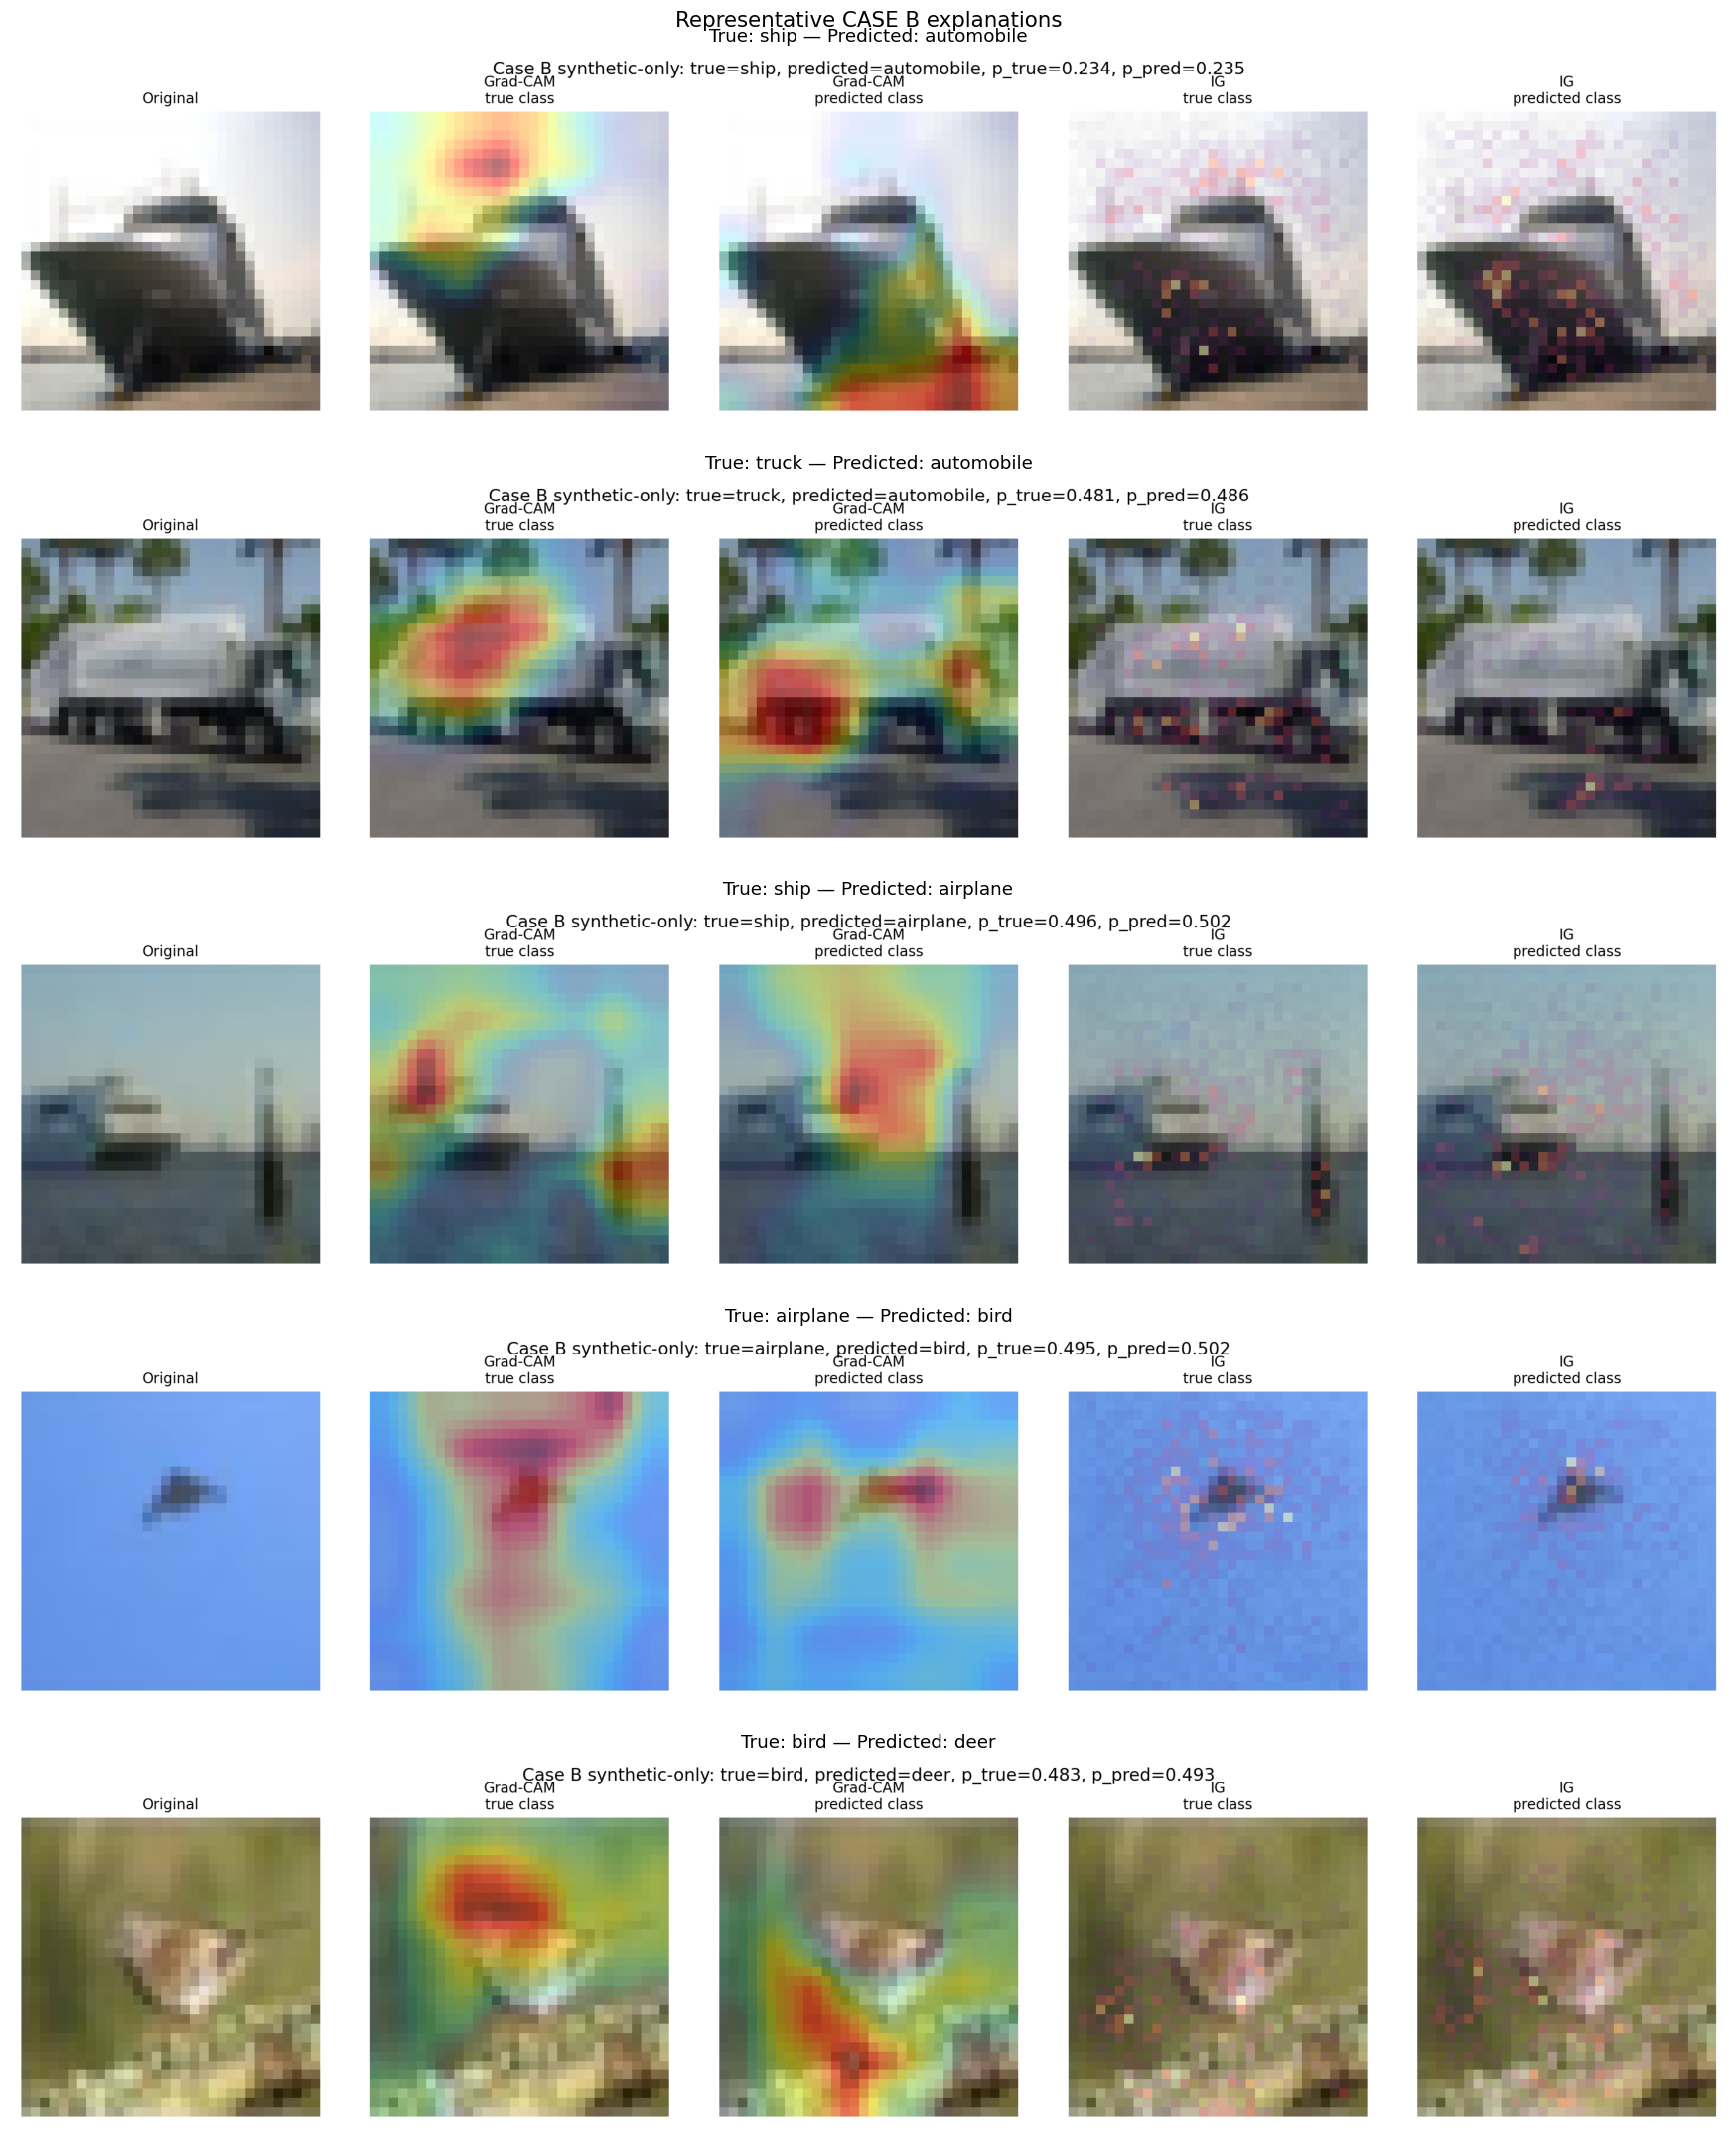

In [13]:
representative_xai = (
    pd.DataFrame(per_image_rows)
    .assign(
        abs_margin=lambda df:
        np.abs(df["confidence_margin_wrong_minus_true"])
    )
    .sort_values("abs_margin")
    .head(5)
)

figure, axes = plt.subplots(
    len(representative_xai),
    1,
    figsize=(16, 4 * len(representative_xai)),
)

if len(representative_xai) == 1:
    axes = [axes]

for axis, (_, row) in zip(
    axes,
    representative_xai.iterrows(),
):
    figure_path = OUTPUT_DIR / row["visualization_path"]

    axis.imshow(
        plt.imread(figure_path)
    )

    axis.set_title(
        f"True: {row['true_class_name']} — "
        f"Predicted: {row['synthetic_predicted_class_name']}"
    )

    axis.axis("off")

figure.suptitle(
    "Representative CASE B explanations",
    fontsize=14,
)

figure.tight_layout()
plt.show()

### Synthetic-model results

Per-image metrics are saved together with summaries by true class and by
true-to-predicted class pair. The CASE B confusion matrix and masking results
are also saved, including both per-image curves and their aggregate summaries.


In [14]:
metric_names = (
    "synthetic_probability_true",
    "synthetic_probability_wrong",
    "confidence_margin_wrong_minus_true",

    "gradcam_true_vs_wrong_pearson",
    "gradcam_true_vs_wrong_top20_iou",

    "ig_true_vs_wrong_pearson",
    "ig_true_vs_wrong_top20_iou",

    "gradcam_true_vs_ig_true_pearson",
    "gradcam_true_vs_ig_true_top20_iou",

    "gradcam_wrong_vs_ig_wrong_pearson",
    "gradcam_wrong_vs_ig_wrong_top20_iou",

    "gradcam_true_deletion_auc",
    "gradcam_true_insertion_auc",

    "gradcam_wrong_deletion_auc",
    "gradcam_wrong_insertion_auc",

    "ig_true_deletion_auc",
    "ig_true_insertion_auc",

    "ig_wrong_deletion_auc",
    "ig_wrong_insertion_auc",
)

true_class_summary_path = (
    OUTPUT_DIR
    / "caseB_summary_by_true_class.csv"
)

pair_summary_path = (
    OUTPUT_DIR
    / "caseB_summary_by_true_predicted_pair.csv"
)

masking_summary_path = (
    OUTPUT_DIR
    / "caseB_masking_summary.csv"
)



save_rows(
    true_class_summary_path,
    summarize_metrics(
        per_image_rows,
        group_fields=(
            "true_class_name",
        ),
        metric_names=metric_names,
    ),
)

save_rows(
    pair_summary_path,
    summarize_metrics(
        per_image_rows,
        group_fields=(
            "true_class_name",
            "synthetic_predicted_class_name",
        ),
        metric_names=metric_names,
    ),
)

masking_summary_rows = (
    summarize_masking_rows(
        masking_rows
    )
)

save_rows(
    masking_summary_path,
    masking_summary_rows,
)


display(
    pd.DataFrame(
        per_image_rows
    )[
        [
            "test_index",
            "true_class_name",
            "synthetic_predicted_class_name",
            "synthetic_probability_true",
            "synthetic_probability_wrong",
            "confidence_margin_wrong_minus_true",

            "gradcam_true_vs_wrong_pearson",
            "gradcam_true_vs_wrong_top20_iou",

            "ig_true_vs_wrong_pearson",
            "ig_true_vs_wrong_top20_iou",

            "gradcam_true_vs_ig_true_pearson",
            "gradcam_true_vs_ig_true_top20_iou",

            "gradcam_wrong_vs_ig_wrong_pearson",
            "gradcam_wrong_vs_ig_wrong_top20_iou",

            "gradcam_true_deletion_auc",
            "gradcam_true_insertion_auc",

            "gradcam_wrong_deletion_auc",
            "gradcam_wrong_insertion_auc",

            "ig_true_deletion_auc",
            "ig_true_insertion_auc",

            "ig_wrong_deletion_auc",
            "ig_wrong_insertion_auc",
        ]
    ].head()
)

display(
    pd.DataFrame(
        masking_summary_rows
    )
)

print(
    "Output synthetic-only:",
    OUTPUT_DIR,
)

,test_index,true_class_name,synthetic_predicted_class_name,synthetic_probability_true,synthetic_probability_wrong,confidence_margin_wrong_minus_true,gradcam_true_vs_wrong_pearson,gradcam_true_vs_wrong_top20_iou,ig_true_vs_wrong_pearson,ig_true_vs_wrong_top20_iou,...,gradcam_wrong_vs_ig_wrong_pearson,gradcam_wrong_vs_ig_wrong_top20_iou,gradcam_true_deletion_auc,gradcam_true_insertion_auc,gradcam_wrong_deletion_auc,gradcam_wrong_insertion_auc,ig_true_deletion_auc,ig_true_insertion_auc,ig_wrong_deletion_auc,ig_wrong_insertion_auc
0,4508,truck,cat,0.003400,0.960168,0.956767,-0.370075,0.002445,0.647669,0.399317,...,0.355407,0.234940,0.000473,0.046507,0.048136,0.437518,0.000173,0.001997,0.048027,0.259690
1,3208,truck,ship,0.183394,0.802944,0.619549,-0.210918,0.048593,0.535364,0.322581,...,0.007832,0.070496,0.045485,0.573485,0.049398,0.264906,0.009212,0.123612,0.048207,0.092420
2,9113,automobile,frog,0.011338,0.923599,0.912261,-0.390412,0.022444,0.568044,0.385135,...,0.196355,0.145251,0.000646,0.177289,0.056343,0.358684,0.000571,0.143878,0.567088,0.812680
3,455,deer,bird,0.001347,0.985559,0.984213,-0.400040,0.027569,0.557659,0.371237,...,0.119347,0.117166,0.044791,0.111046,0.484455,0.583925,0.035178,0.001925,0.222009,0.507617
4,6532,dog,horse,0.000132,0.999677,0.999545,0.691696,0.375839,0.507446,0.309904,...,0.192516,0.154930,0.000043,0.217701,0.151852,0.449682,0.000007,0.000008,0.049984,0.263901


,saliency_name,fraction,count,true_probability_change_mean,true_probability_change_std,wrong_probability_drop_mean,wrong_probability_drop_std,prediction_flipped_mean,prediction_flipped_std,prediction_flipped_to_true_mean,prediction_flipped_to_true_std
0,gradcam_true,0.00,901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,gradcam_true,0.05,901,0.015807,0.228901,0.121876,0.324056,0.251942,0.434128,0.094340,0.292301
2,gradcam_true,0.10,901,-0.003751,0.234287,0.175905,0.384166,0.312986,0.463709,0.081021,0.272867
3,gradcam_true,0.20,901,-0.011045,0.248235,0.279796,0.423965,0.427303,0.494687,0.082131,0.274564
4,gradcam_true,0.30,901,-0.015311,0.249087,0.368934,0.446444,0.520533,0.499578,0.074362,0.262359
5,gradcam_true,0.40,901,-0.012238,0.259500,0.462670,0.443509,0.622642,0.484726,0.078801,0.269428
6,gradcam_true,0.50,901,-0.020661,0.249856,0.535184,0.422576,0.701443,0.457625,0.071032,0.256879
7,gradcam_wrong,0.00,901,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,gradcam_wrong,0.05,901,0.155793,0.310127,0.324815,0.360721,0.463929,0.498697,0.244173,0.429596
9,gradcam_wrong,0.10,901,0.197819,0.355601,0.455500,0.384733,0.619312,0.485556,0.288568,0.453097


Output synthetic-only: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/synthetic_model


## Masking results

Masking curves summarize the effect of progressively removing the most salient
regions identified for the true and incorrectly predicted classes.

We evaluate both the decrease in incorrect-class probability and the fraction
of CASE B images for which the synthetic-trained classifier shifts to the true
class after masking.


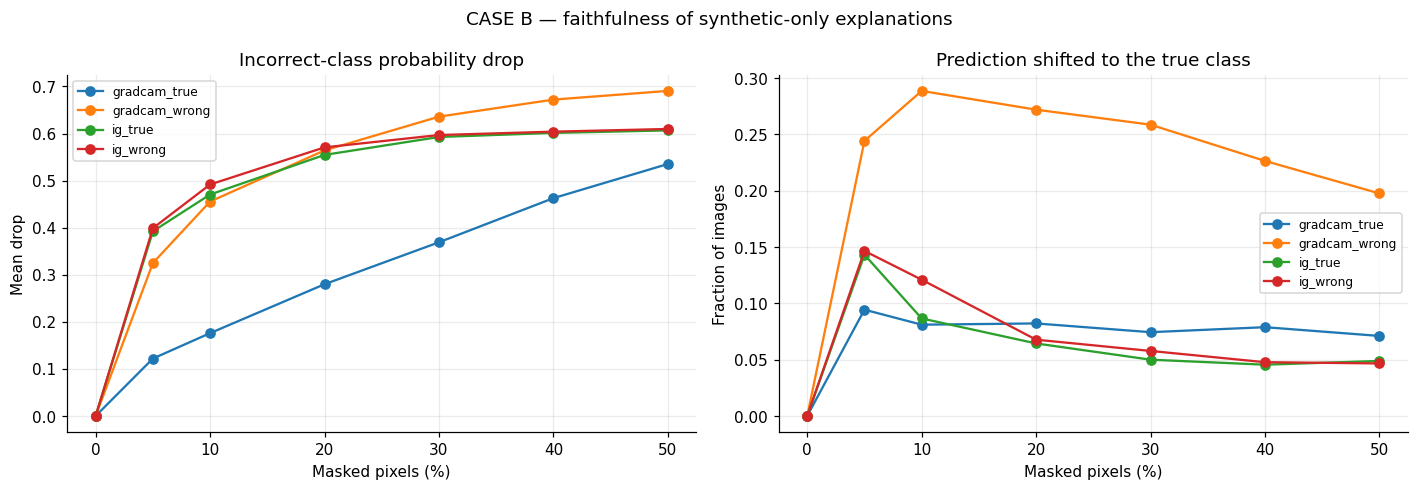

In [15]:
masking_summary_df = pd.DataFrame(masking_summary_rows)
figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for saliency_name, group in masking_summary_df.groupby("saliency_name"):
    group = group.sort_values("fraction")
    axes[0].plot(
        100 * group["fraction"],
        group["wrong_probability_drop_mean"],
        marker="o",
        label=saliency_name,
    )
    axes[1].plot(
        100 * group["fraction"],
        group["prediction_flipped_to_true_mean"],
        marker="o",
        label=saliency_name,
    )

axes[0].set_title("Incorrect-class probability drop")
axes[0].set_ylabel("Mean drop")
axes[1].set_title("Prediction shifted to the true class")
axes[1].set_ylabel("Fraction of images")
for axis in axes:
    axis.set_xlabel("Masked pixels (%)")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
figure.suptitle("CASE B — faithfulness of synthetic-only explanations")
figure.tight_layout()
figure.savefig(OUTPUT_DIR / "caseB_masking_curves.png", dpi=180)
plt.show()


## LIME analysis

For the synthetic-trained classifier, LIME explanations are computed for both
the true class and the incorrectly predicted class.

The analysis compares their top positive regions and evaluates the effect of
progressively masking the regions supporting the incorrect prediction.

Total LIME CASE B images: 200
LIME CASE B results loaded from: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/lime


,true_class_name,count,mean,std
0,airplane,20,0.018869,0.053418
1,automobile,20,0.087870,0.123593
2,bird,20,0.077105,0.082940
3,cat,20,0.151977,0.142521
4,deer,20,0.041244,0.061176
5,dog,20,0.201144,0.188935
6,frog,20,0.141390,0.179956
7,horse,20,0.124405,0.124469
8,ship,20,0.090320,0.111592
9,truck,20,0.214688,0.198373


,fraction,wrong_probability_drop_mean,wrong_probability_drop_std,recovered_to_true_rate
0,0.0,0.000000,0.000000,0.000
1,0.2,0.669953,0.302464,0.410
2,0.4,0.796108,0.229289,0.365
3,0.6,0.811107,0.211105,0.330
4,0.8,0.825438,0.206760,0.305
5,1.0,0.828225,0.194522,0.275


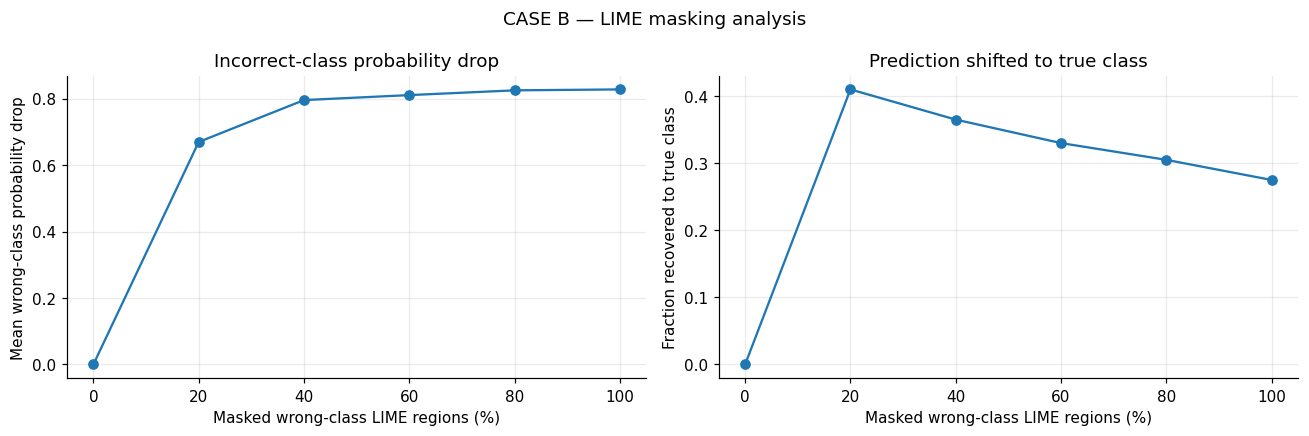

Output LIME CASE B: /home/matteo.doria/Desktop/xAI-Project/Results/Exp_xAI/cifar10/classifier/caseB/lime


In [16]:
import warnings
from tqdm import TqdmWarning

# tqdm warns once that ipywidgets is missing: harmless, text bars would be used.
warnings.filterwarnings("ignore", category=TqdmWarning)

from lime import lime_image
from skimage.segmentation import slic, mark_boundaries

# lime 0.2.0.1 draws one tqdm bar per explanation (200 here) and has no option
# to turn it off: replace its module-level tqdm with a pass-through.
lime_image.tqdm = lambda iterable, *args, **kwargs: iterable

LIME_CASE_B_DIR.mkdir(parents=True, exist_ok=True)
LIME_CASE_B_VISUALS_DIR.mkdir(parents=True, exist_ok=True)

LIME_IMAGES_PER_CLASS = 20
LIME_NUM_SAMPLES = 1000
LIME_TOP_K = 5
LIME_N_SEGMENTS = 20

LIME_MASK_FRACTIONS = (
    0.00,
    0.20,
    0.40,
    0.60,
    0.80,
    1.00,
)

lime_explainer = lime_image.LimeImageExplainer(
    random_state=SEED
)


def lime_predict_fn(model):
    def predict(images):
        images = np.asarray(
            images,
            dtype=np.float32,
        )

        return model.predict(
            images,
            batch_size=256,
            verbose=0,
        )

    return predict


def lime_segmentation(image):
    return slic(
        image,
        n_segments=LIME_N_SEGMENTS,
        compactness=10,
        sigma=1,
        start_label=0,
        channel_axis=-1,
    )


def positive_lime_regions(
    explanation,
    target_class,
):
    regions = [
        (region_id, weight)
        for region_id, weight
        in explanation.local_exp[target_class]
        if weight > 0
    ]

    regions.sort(
        key=lambda item: item[1],
        reverse=True,
    )

    return regions


def region_mask(segments, region_ids):
    return np.isin(
        segments,
        region_ids,
    )


def jaccard_masks(first_mask, second_mask):
    intersection = np.logical_and(
        first_mask,
        second_mask,
    ).sum()

    union = np.logical_or(
        first_mask,
        second_mask,
    ).sum()

    if union == 0:
        return np.nan

    return float(
        intersection / union
    )


def mask_lime_regions(
    image,
    segments,
    region_ids,
):
    mask = region_mask(
        segments,
        region_ids,
    )

    baseline = np.broadcast_to(
        CIFAR10_MEAN,
        image.shape,
    ).astype(np.float32)

    return np.where(
        mask[..., None],
        baseline,
        image,
    )


def save_case_b_lime_figure(
    path,
    image,
    true_mask,
    wrong_mask,
    true_class,
    wrong_class,
):
    figure, axes = plt.subplots(
        1,
        3,
        figsize=(10, 3.5),
    )

    axes[0].imshow(image)
    axes[0].set_title(
        "Original\n"
        f"True: {CIFAR10_CLASSES[true_class]}\n"
        f"Pred: {CIFAR10_CLASSES[wrong_class]}"
    )

    axes[1].imshow(
        mark_boundaries(
            image,
            true_mask.astype(int),
        )
    )
    axes[1].imshow(
        true_mask,
        cmap="Greens",
        alpha=0.30,
    )
    axes[1].set_title(
        "LIME\nTrue class"
    )

    axes[2].imshow(
        mark_boundaries(
            image,
            wrong_mask.astype(int),
        )
    )
    axes[2].imshow(
        wrong_mask,
        cmap="Reds",
        alpha=0.30,
    )
    axes[2].set_title(
        "LIME\nWrong class"
    )

    for axis in axes:
        axis.axis("off")

    figure.tight_layout()

    figure.savefig(
        path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.close(figure)


rng = np.random.default_rng(SEED)

lime_case_b_indices = []

for class_id in range(len(CIFAR10_CLASSES)):
    class_indices = [
        idx
        for idx in selected_indices
        if int(y_test[idx]) == class_id
    ]

    sample_size = min(
        LIME_IMAGES_PER_CLASS,
        len(class_indices),
    )

    if sample_size == 0:
        continue

    selected = rng.choice(
        class_indices,
        size=sample_size,
        replace=False,
    )

    lime_case_b_indices.extend(
        selected.tolist()
    )

rng.shuffle(lime_case_b_indices)

lime_case_b_indices = np.asarray(
    lime_case_b_indices,
    dtype=int,
)

print(
    "Total LIME CASE B images:",
    len(lime_case_b_indices),
)

lime_case_b_cached = (
    LIME_CASE_B_PER_IMAGE_CSV.exists()
    and LIME_CASE_B_MASKING_CSV.exists()
    and not FORCE_RECOMPUTE
)

if lime_case_b_cached:
    lime_case_b_df = pd.read_csv(LIME_CASE_B_PER_IMAGE_CSV)
    lime_case_b_masking_df = pd.read_csv(LIME_CASE_B_MASKING_CSV)
    print("LIME CASE B results loaded from:", LIME_CASE_B_DIR)
else:

    lime_case_b_rows = []
    lime_case_b_masking_rows = []

    for processed_count, test_index in enumerate(
        lime_case_b_indices,
        start=1,
    ):
        image = x_test[test_index]
        true_class = int(y_test[test_index])

        probabilities = models["synthetic"](
            image[None, ...],
            training=False,
        )[0].numpy()

        wrong_class = int(
            np.argmax(probabilities)
        )

        assert (
            predictions["real"][test_index]
            == true_class
        )

        assert wrong_class != true_class

        segments = lime_segmentation(
            image
        )

        segmentation_fn = lambda _: segments

        explanation = lime_explainer.explain_instance(
            image,
            lime_predict_fn(
                models["synthetic"]
            ),
            labels=(
                true_class,
                wrong_class,
            ),
            top_labels=None,
            num_samples=LIME_NUM_SAMPLES,
            segmentation_fn=segmentation_fn,
            hide_color=CIFAR10_MEAN,
        )

        true_regions_weighted = (
            positive_lime_regions(
                explanation,
                true_class,
            )
        )

        wrong_regions_weighted = (
            positive_lime_regions(
                explanation,
                wrong_class,
            )
        )

        true_top_regions = [
            region_id
            for region_id, _
            in true_regions_weighted[:LIME_TOP_K]
        ]

        wrong_top_regions = [
            region_id
            for region_id, _
            in wrong_regions_weighted[:LIME_TOP_K]
        ]

        true_mask = region_mask(
            segments,
            true_top_regions,
        )

        wrong_mask = region_mask(
            segments,
            wrong_top_regions,
        )

        overlap = jaccard_masks(
            true_mask,
            wrong_mask,
        )

        lime_case_b_rows.append({
            "test_index": int(test_index),
            "true_class_id": true_class,
            "true_class_name":
                CIFAR10_CLASSES[true_class],
            "wrong_class_id": wrong_class,
            "wrong_class_name":
                CIFAR10_CLASSES[wrong_class],
            "lime_true_wrong_top5_jaccard":
                overlap,
        })

        class_dir = (
            LIME_CASE_B_VISUALS_DIR
            / f"{true_class}_{CIFAR10_CLASSES[true_class]}"
        )

        class_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        save_case_b_lime_figure(
            class_dir
            / f"lime_index_{test_index}.png",
            image,
            true_mask,
            wrong_mask,
            true_class,
            wrong_class,
        )

        ranked_wrong_regions = [
            region_id
            for region_id, _
            in wrong_regions_weighted
        ]

        original_wrong_probability = float(
            probabilities[wrong_class]
        )

        for fraction in LIME_MASK_FRACTIONS:

            number_to_mask = int(
                round(
                    fraction
                    * len(ranked_wrong_regions)
                )
            )

            regions_to_mask = (
                ranked_wrong_regions[
                    :number_to_mask
                ]
            )

            masked_image = mask_lime_regions(
                image,
                segments,
                regions_to_mask,
            )

            masked_probabilities = (
                models["synthetic"](
                    masked_image[None, ...],
                    training=False,
                )[0].numpy()
            )

            masked_prediction = int(
                np.argmax(masked_probabilities)
            )

            lime_case_b_masking_rows.append({
                "test_index": int(test_index),
                "fraction": float(fraction),

                "wrong_probability_drop": float(
                    original_wrong_probability
                    - masked_probabilities[
                        wrong_class
                    ]
                ),

                "recovered_to_true": int(
                    masked_prediction
                    == true_class
                ),
            })

        if (
            processed_count % 25 == 0
            or processed_count
            == len(lime_case_b_indices)
        ):
            print(
                f"LIME CASE B: "
                f"{processed_count}/"
                f"{len(lime_case_b_indices)}"
            )


    lime_case_b_df = pd.DataFrame(
        lime_case_b_rows
    )

    lime_case_b_masking_df = pd.DataFrame(
        lime_case_b_masking_rows
    )


    lime_case_b_df.to_csv(LIME_CASE_B_PER_IMAGE_CSV, index=False)
    lime_case_b_masking_df.to_csv(LIME_CASE_B_MASKING_CSV, index=False)
    print("LIME CASE B results saved to:", LIME_CASE_B_DIR)

# Saved results must refer to the LIME images selected above, in the same order.
assert np.array_equal(lime_case_b_df["test_index"].to_numpy(), lime_case_b_indices), (
    "Saved LIME CASE B results do not match the LIME CASE B indices: "
    "set FORCE_RECOMPUTE = True and rerun."
)

lime_case_b_summary = (
    lime_case_b_df
    .groupby("true_class_name")[
        "lime_true_wrong_top5_jaccard"
    ]
    .agg(["count", "mean", "std"])
    .reset_index()
)

lime_case_b_summary.to_csv(
    LIME_CASE_B_DIR
    / "lime_caseB_summary.csv",
    index=False,
)


lime_masking_summary = (
    lime_case_b_masking_df
    .groupby("fraction")
    .agg(
        wrong_probability_drop_mean=(
            "wrong_probability_drop",
            "mean",
        ),
        wrong_probability_drop_std=(
            "wrong_probability_drop",
            "std",
        ),
        recovered_to_true_rate=(
            "recovered_to_true",
            "mean",
        ),
    )
    .reset_index()
)

lime_masking_summary.to_csv(
    LIME_CASE_B_DIR
    / "lime_caseB_masking_summary.csv",
    index=False,
)

display(lime_case_b_summary)
display(lime_masking_summary)


figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

axes[0].plot(
    100 * lime_masking_summary["fraction"],
    lime_masking_summary[
        "wrong_probability_drop_mean"
    ],
    marker="o",
)

axes[0].set_xlabel(
    "Masked wrong-class LIME regions (%)"
)

axes[0].set_ylabel(
    "Mean wrong-class probability drop"
)

axes[0].set_title(
    "Incorrect-class probability drop"
)

axes[0].grid(
    alpha=0.25
)


axes[1].plot(
    100 * lime_masking_summary["fraction"],
    lime_masking_summary[
        "recovered_to_true_rate"
    ],
    marker="o",
)

axes[1].set_xlabel(
    "Masked wrong-class LIME regions (%)"
)

axes[1].set_ylabel(
    "Fraction recovered to true class"
)

axes[1].set_title(
    "Prediction shifted to true class"
)

axes[1].grid(
    alpha=0.25
)

figure.suptitle(
    "CASE B — LIME masking analysis"
)

figure.tight_layout()

figure.savefig(
    LIME_CASE_B_DIR
    / "lime_caseB_masking_curves.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    "Output LIME CASE B:",
    LIME_CASE_B_DIR,
)

In [17]:
display(lime_case_b_summary)
display(lime_masking_summary)

,true_class_name,count,mean,std
0,airplane,20,0.018869,0.053418
1,automobile,20,0.087870,0.123593
2,bird,20,0.077105,0.082940
3,cat,20,0.151977,0.142521
4,deer,20,0.041244,0.061176
5,dog,20,0.201144,0.188935
6,frog,20,0.141390,0.179956
7,horse,20,0.124405,0.124469
8,ship,20,0.090320,0.111592
9,truck,20,0.214688,0.198373


,fraction,wrong_probability_drop_mean,wrong_probability_drop_std,recovered_to_true_rate
0,0.0,0.000000,0.000000,0.000
1,0.2,0.669953,0.302464,0.410
2,0.4,0.796108,0.229289,0.365
3,0.6,0.811107,0.211105,0.330
4,0.8,0.825438,0.206760,0.305
5,1.0,0.828225,0.194522,0.275


### Random LIME examples

Five CASE B images are randomly selected from the subset analyzed with LIME.

For each image, we visualize the regions positively supporting the true class
and the incorrectly predicted class within the synthetic-trained classifier.

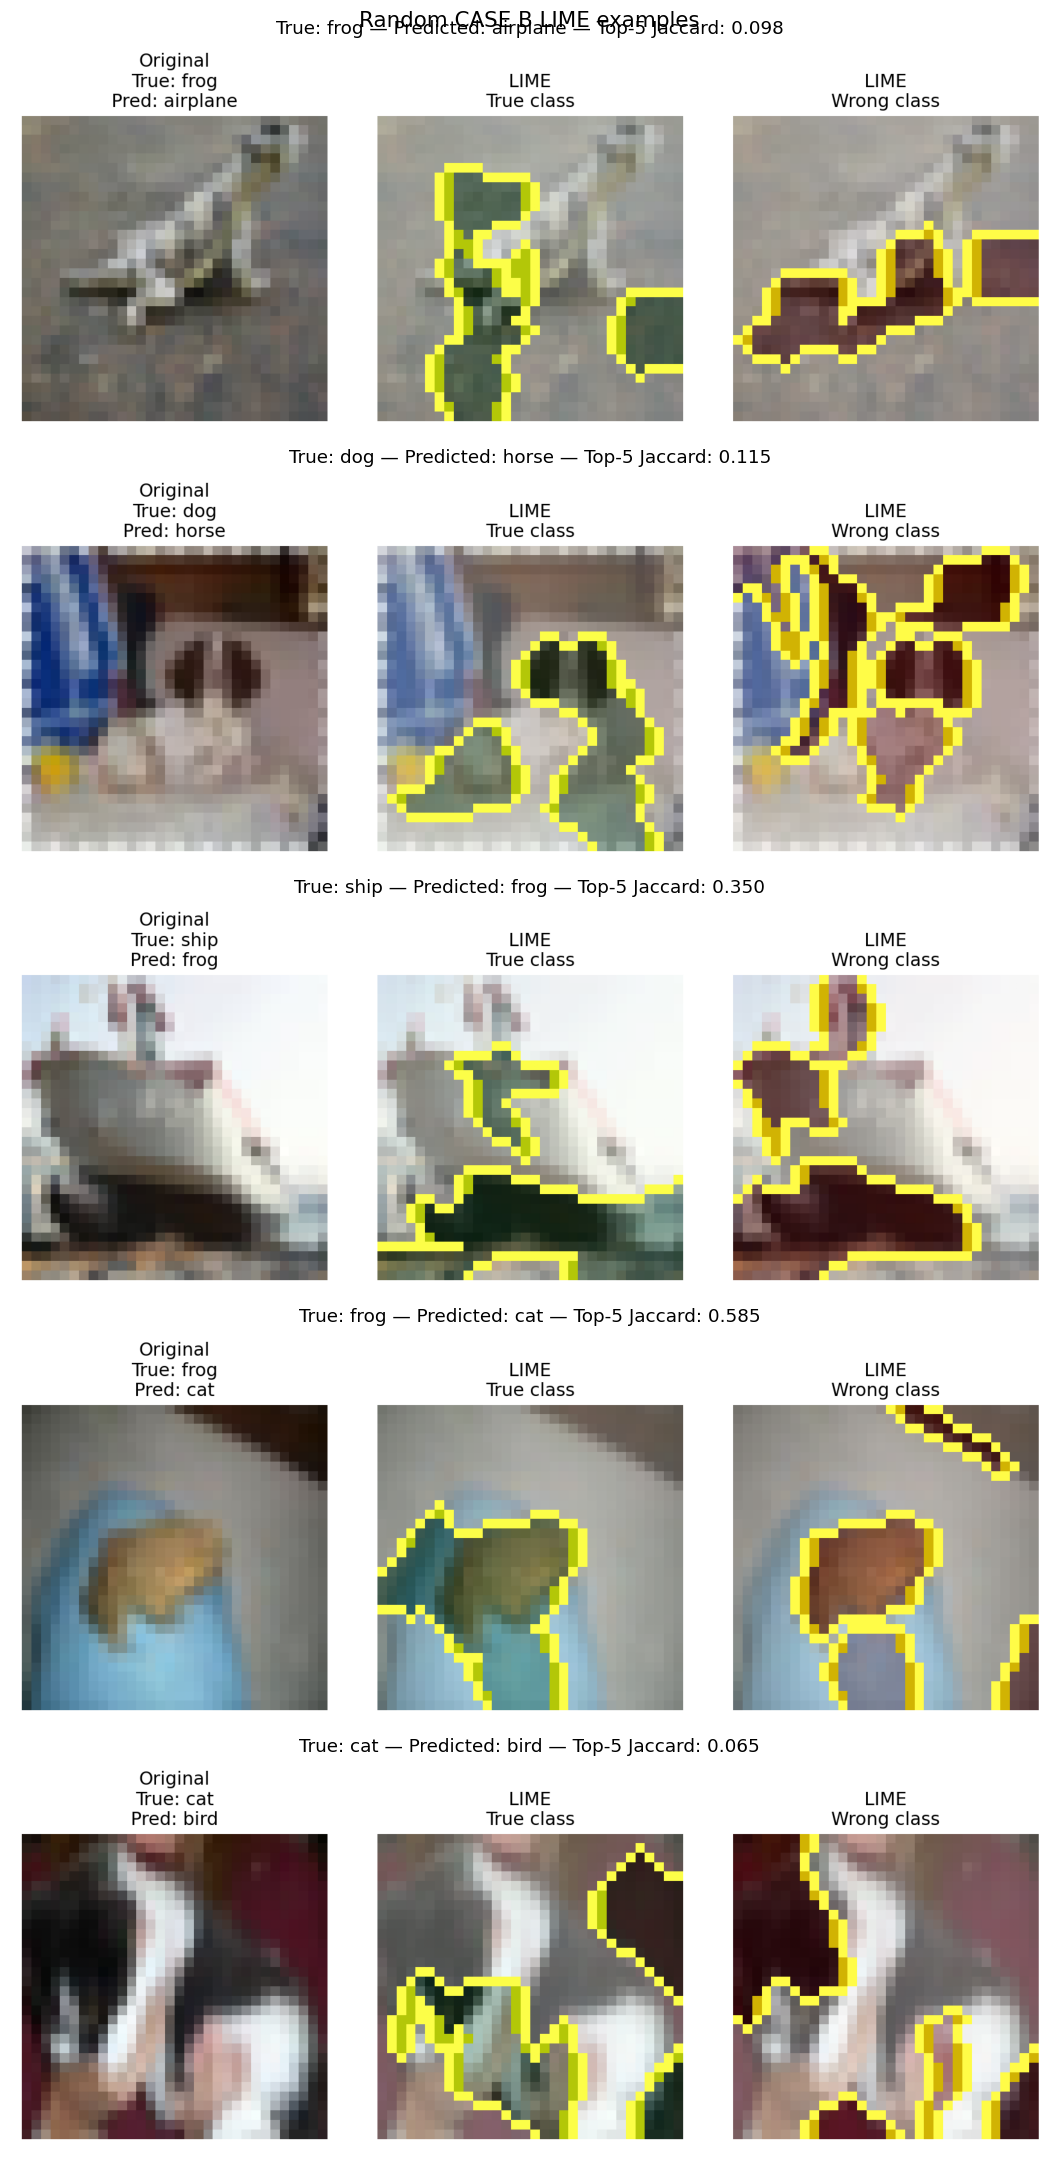

In [18]:
rng = np.random.default_rng(SEED)

n_examples = min(
    5,
    len(lime_case_b_df),
)

random_examples = (
    lime_case_b_df
    .sample(
        n=n_examples,
        random_state=SEED,
    )
)

figure, axes = plt.subplots(
    n_examples,
    1,
    figsize=(12, 4 * n_examples),
)

if n_examples == 1:
    axes = [axes]

for axis, (_, row) in zip(
    axes,
    random_examples.iterrows(),
):
    test_index = int(row["test_index"])
    class_id = int(row["true_class_id"])
    class_name = row["true_class_name"]

    image_path = (
        LIME_CASE_B_VISUALS_DIR
        / f"{class_id}_{class_name}"
        / f"lime_index_{test_index}.png"
    )

    axis.imshow(
        plt.imread(image_path)
    )

    axis.set_title(
        f"True: {class_name} — "
        f"Predicted: {row['wrong_class_name']} — "
        f"Top-5 Jaccard: "
        f"{row['lime_true_wrong_top5_jaccard']:.3f}"
    )

    axis.axis("off")

figure.suptitle(
    "Random CASE B LIME examples",
    fontsize=14,
)

figure.tight_layout()
plt.show()